
# 1. Configuración Inicial


*   Importación de las librerías necesarias
*   Montaje del Drive (Base de Datos)




In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Configuración del Pipeline


*   Tamaño de imagen
*   Tamaño de lote
*   Número de clases
*   Mejora eficiencia del modelo
*   Ruta de imágenes train y test
*   Parámetros configurables para el pipeline de mejora de imágenes



In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
AUTO = tf.data.AUTOTUNE

train_path = "/content/drive/MyDrive/DATASET/train"
test_path  = "/content/drive/MyDrive/DATASET/test"
clases = ["Fuego", "Humo", "No Fuego"]

CONFIG = {
    "color_space": "HSV",
    "use_gamma": True,
    "use_contrast": True,
    "use_hist_eq": True,
    "use_hist_spec": False,
    "use_bilateral": False,
    "use_erode": True,
    "use_dilate": True,
    "gamma_value": 0.7,
    "contrast_alpha": 1.0,
    "contrast_beta": 0,
    "hist_spec_reference": "ref.jpg",
    "bilateral_d": 5,
    "bilateral_sigmaColor": 50,
    "bilateral_sigmaSpace": 75,
    "kernel_size": 3
}

# 3. Creación de conjuntos finales de datos
Un conjunto para train, otro conjunto para test

In [ ]:
def crear_dataframe(base_path):
    data = []
    for idx, clase in enumerate(clases):
        carpeta = os.path.join(base_path, clase)
        if not os.path.isdir(carpeta):
            print(f"⚠️ Carpeta no encontrada: {carpeta}")
            continue
        for fname in os.listdir(carpeta):
            fpath = os.path.join(carpeta, fname)
            if os.path.isfile(fpath):
                data.append([fpath, idx])
    return pd.DataFrame(data, columns=["filepath", "label_num"])

train_df = crear_dataframe(train_path)
test_df  = crear_dataframe(test_path)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (1576, 2)
Test: (115, 2)


# 4. Definición de funciones auxiliares que ayudarán al procesamiento de las imágenes



*   Espacio de color
*   Corrección gamma
*   Ajuste de contraste
*   Ecualización de histograma
*   Especificación de histograma
*   Filtro bilateral
*   Erosión
*   Dilatación



In [ ]:
def to_color_space(img, mode="LAB"):
    if mode == "HSV":
        return cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    elif mode == "LAB":
        return cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    return img

def adaptive_gamma_correction(img, gamma=1.0):
    img_norm = img / 255.0
    corrected = np.power(img_norm, gamma)
    return (corrected * 255).astype(np.uint8)

def adjust_contrast(img, alpha=1.0, beta=0):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def histogram_equalization(img, space="LAB"):
    if space == "HSV":
        # HSV: channel V is index 2
        img[:, :, 2] = cv2.equalizeHist(img[:, :, 2])
    else:  # LAB: channel L is index 0
        img[:, :, 0] = cv2.equalizeHist(img[:, :, 0])
    return img

def histogram_specification(img, reference_path):
    reference = cv2.imread(reference_path)
    if reference is None:
        print("No se pudo cargar la imagen de referencia para especificación:", reference_path)
        return img

    reference = cv2.cvtColor(reference, cv2.COLOR_BGR2LAB)
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    out = img_lab.copy()

    for channel in range(3):
        src = img_lab[:, :, channel].ravel()
        ref = reference[:, :, channel].ravel()

        src_hist, _ = np.histogram(src, 256, [0, 256])
        ref_hist, _ = np.histogram(ref, 256, [0, 256])

        # evitar división por cero
        if src_hist.sum() == 0 or ref_hist.sum() == 0:
            continue

        src_cdf = src_hist.cumsum() / src_hist.sum()
        ref_cdf = ref_hist.cumsum() / ref_hist.sum()

        mapping = np.interp(src_cdf, ref_cdf, np.arange(256))
        out[:, :, channel] = mapping[src].reshape(img_lab[:, :, channel].shape)

    return cv2.cvtColor(out, cv2.COLOR_LAB2BGR)

def bilateral_filter(img, d, sc, ss):
    return cv2.bilateralFilter(img, d, sc, ss)

def erode(img, ksize):
    kernel = np.ones((ksize, ksize), np.uint8)
    return cv2.erode(img, kernel, iterations=1)

def dilate(img, ksize):
    kernel = np.ones((ksize, ksize), np.uint8)
    return cv2.dilate(img, kernel, iterations=1)

# 4.1 Pipeline de mejoramiento de imágenes

In [ ]:
def process_image(img, cfg):
    # img: BGR uint8
    original = img.copy()

    # Convertir espacio de color para procesamiento
    img_proc = to_color_space(img, cfg.get("color_space", "LAB"))

    # Gamma
    if cfg.get("use_gamma", False):
        img_proc = adaptive_gamma_correction(img_proc, cfg.get("gamma_value", 1.0))

    # Contraste
    if cfg.get("use_contrast", False):
        img_proc = adjust_contrast(img_proc, cfg.get("contrast_alpha",1.0), cfg.get("contrast_beta",0))

    # Ecualización
    if cfg.get("use_hist_eq", False):
        img_proc = histogram_equalization(img_proc, cfg.get("color_space","LAB"))

    # Especificación de histograma (opcional)
    if cfg.get("use_hist_spec", False) and cfg.get("hist_spec_reference"):
        img_proc = histogram_specification(original, cfg.get("hist_spec_reference"))

    # Bilateral
    if cfg.get("use_bilateral", False):
        img_proc = bilateral_filter(img_proc, cfg.get("bilateral_d",5),
                                    cfg.get("bilateral_sigmaColor",50),
                                    cfg.get("bilateral_sigmaSpace",75))

    # Dilate / Erode (aplicar en este orden si se pidió)
    if cfg.get("use_dilate", False):
        img_proc = dilate(img_proc, cfg.get("kernel_size",3))
    if cfg.get("use_erode", False):
        img_proc = erode(img_proc, cfg.get("kernel_size",3))

    # Regresar a BGR (si se procesó en otro espacio)
    if cfg.get("color_space","LAB") == "HSV":
        try:
            img_proc = cv2.cvtColor(img_proc, cv2.COLOR_HSV2BGR)
        except:
            pass
    elif cfg.get("color_space","LAB") == "LAB":
        try:
            img_proc = cv2.cvtColor(img_proc, cv2.COLOR_LAB2BGR)
        except:
            pass

    return img_proc

# 5. Funciones para una carga robusta, junto con augmentación de las imágenes

In [ ]:
def cargar_imagen(path, label, aplicar_mejora=False, aplicar_augment=False):
    p = path.numpy().decode("utf-8")
    lbl = int(label.numpy()) if hasattr(label, "numpy") else int(label)

    img = cv2.imread(p)
    if img is None:
        # imagen inválida
        img = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    else:
        img = cv2.resize(img, (IMAGE_SIZE[1], IMAGE_SIZE[0]))

    if aplicar_mejora:
        try:
            img = process_image(img, CONFIG)
        except Exception as e:
            print("⚠️ error en process_image:", e)
            img = img

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    if aplicar_augment:
        if np.random.rand() > 0.5:
            img = np.fliplr(img)
        img = np.clip(img + (np.random.rand()*0.15 - 0.075), 0.0, 1.0)

    return img.astype(np.float32), np.int32(lbl)

# Wrapper para usar en tf.data
def wrapper(path, label, aplicar_mejora=False, aplicar_augment=False):
    img, lab = tf.py_function(
        func=lambda p, l: cargar_imagen(p, l, aplicar_mejora, aplicar_augment),
        inp=[path, label],
        Tout=[tf.float32, tf.int32]
    )
    img.set_shape([IMAGE_SIZE[0], IMAGE_SIZE[1], 3])
    lab.set_shape([])
    return img, lab

# 6. Función para la creación de los Dataset original y Dataset modificado, es decir, con las imágenes pre procesadas con los filtros.

In [ ]:
def crear_dataset(df, aplicar_mejora=False, aplicar_augment=False, shuffle=True):
    paths = df.filepath.values
    labels = df.label_num.values.astype(np.int32)   # <-- aseguramos int32
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: wrapper(p, l, aplicar_mejora, aplicar_augment),
                num_parallel_calls=AUTO)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

# generar datasets
train_original = crear_dataset(train_df, aplicar_mejora=False, aplicar_augment=False)
test_original  = crear_dataset(test_df, aplicar_mejora=False, aplicar_augment=False)

train_mejorado = crear_dataset(train_df, aplicar_mejora=True, aplicar_augment=True)
test_mejorado  = crear_dataset(test_df, aplicar_mejora=True, aplicar_augment=False)

# 7. Definición de la arquitectura de los modelos.



*   Se definió el número de neuronas por capa con activación ReLu
*   Se definió la métrica a utilizar



In [ ]:
def build_model(base_model):
    base_model.trainable = False
    inputs = layers.Input(shape=IMAGE_SIZE + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# 8 Entrenamiento con MobileNetV2


In [ ]:
# 8) ENTRENAMIENTO: MobileNetV2 (original y mejorado)
# ============================================
print(">>> Entrenando MobileNetV2 con dataset ORIGINAL")
base_m = MobileNetV2(input_shape=IMAGE_SIZE+(3,), include_top=False, weights="imagenet")
model_m = build_model(base_m)
hist_m_orig = model_m.fit(train_original, validation_data=test_original, epochs=10)
acc_m_orig = model_m.evaluate(test_original)[1]
model_m.save("MobileNetV2_original.keras")
print("MobileNetV2 original guardado.")

print("\n>>> Entrenando MobileNetV2 con dataset MEJORADO")
base_m2 = MobileNetV2(input_shape=IMAGE_SIZE+(3,), include_top=False, weights="imagenet")
model_m2 = build_model(base_m2)
hist_m_mej = model_m2.fit(train_mejorado, validation_data=test_mejorado, epochs=10)
acc_m_mej = model_m2.evaluate(test_mejorado)[1]
model_m2.save("MobileNetV2_mejorado.keras")
print("MobileNetV2 mejorado guardado.")


>>> Entrenando MobileNetV2 con dataset ORIGINAL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.5336 - loss: 1.0309 - val_accuracy: 0.6348 - val_loss: 0.8418
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.8012 - loss: 0.5205 - val_accuracy: 0.7130 - val_loss: 0.6783
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.8522 - loss: 0.4281 - val_accuracy: 0.7391 - val_loss: 0.6594
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.8857 - loss: 0.3383 - val_accuracy: 0.7217 - val_loss: 0.6889
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.9110 - loss: 0.2769 - val_accuracy: 0.7565 - val_loss: 0.6399
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.9043 - loss: 0.2643 - val_accuracy: 0.7739 - val_loss: 0.6194
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.9214 - loss: 0.2134 - val_accuracy: 0.7826 - val_loss: 0.6042
Ep

# 8.1 Entrenamiento con EfficientNetB0
Útil para comparar rendimiento entre diversas arquitecturas

In [ ]:
# 8) OPCIONAL: EfficientNetB0 (misma estructura)
# ============================================
print("\n>>> (Opcional) Entrenando EfficientNetB0 con dataset ORIGINAL")
base_e = EfficientNetB0(input_shape=IMAGE_SIZE+(3,), include_top=False, weights="imagenet")
model_e = build_model(base_e)
hist_e_orig = model_e.fit(train_original, validation_data=test_original, epochs=8)
acc_e_orig = model_e.evaluate(test_original)[1]
model_e.save("EfficientNetB0_original.keras")
print("EfficientNetB0 original guardado.")

print("\n>>> (Opcional) Entrenando EfficientNetB0 con dataset MEJORADO")
base_e2 = EfficientNetB0(input_shape=IMAGE_SIZE+(3,), include_top=False, weights="imagenet")
model_e2 = build_model(base_e2)
hist_e_mej = model_e2.fit(train_mejorado, validation_data=test_mejorado, epochs=8)
acc_e_mej = model_e2.evaluate(test_mejorado)[1]
model_e2.save("EfficientNetB0_mejorado.keras")
print("EfficientNetB0 mejorado guardado.")


>>> (Opcional) Entrenando EfficientNetB0 con dataset ORIGINAL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 779ms/step - accuracy: 0.4819 - loss: 1.0401 - val_accuracy: 0.4609 - val_loss: 1.1179
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.4965 - loss: 1.0767 - val_accuracy: 0.4609 - val_loss: 1.1432
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.4788 - loss: 1.0959 - val_accuracy: 0.4609 - val_loss: 1.1384
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.4490 - loss: 1.1245 - val_accuracy: 0.4609 - val_loss: 1.1627
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.4726 - loss: 1.1139 - val_accuracy: 0.4609 - val_loss: 1.1271
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.4853 - loss: 1.0847 - val_accuracy: 0.4609 - val_loss: 1.1323
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 211ms/step - accuracy: 0.4749 - loss: 1.0871 - val_accuracy: 0.4609 - val_los

# 9. Visualización y comparativa de los resultados obtenidos

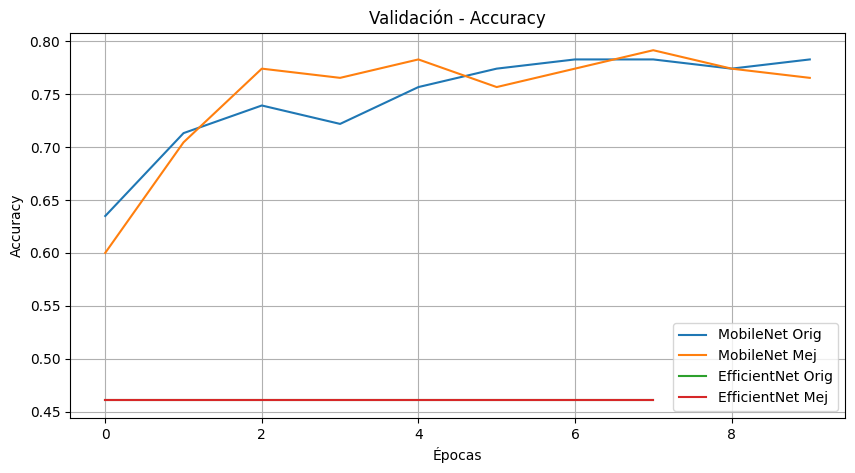


RESULTADOS FINALES:
MobileNetV2 original: 0.782608687877655
MobileNetV2 mejorado: 0.7652173638343811
EfficientNetB0 original: 0.46086955070495605
EfficientNetB0 mejorado: 0.46086955070495605


In [ ]:
# 9) GRAFICAS Y COMPARATIVA
# ============================================
plt.figure(figsize=(10,5))
plt.plot(hist_m_orig.history["val_accuracy"], label="MobileNet Orig")
plt.plot(hist_m_mej.history["val_accuracy"], label="MobileNet Mej")
if 'hist_e_orig' in locals():
    plt.plot(hist_e_orig.history["val_accuracy"], label="EfficientNet Orig")
if 'hist_e_mej' in locals():
    plt.plot(hist_e_mej.history["val_accuracy"], label="EfficientNet Mej")
plt.title("Validación - Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

print("\nRESULTADOS FINALES:")
print("MobileNetV2 original:", acc_m_orig)
print("MobileNetV2 mejorado:", acc_m_mej)
if 'acc_e_orig' in locals():
    print("EfficientNetB0 original:", acc_e_orig)
    print("EfficientNetB0 mejorado:", acc_e_mej)
